In [1]:
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [38]:
import nibabel as nib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import Counter

from datasets.dbb import DBB

In [3]:
DBB_DATASET_FOLDER = "/run/media/gianluca/Hard_drive/DBB"

In [4]:
from ipywidgets import interact, IntSlider, Dropdown
import ipywidgets as widgets
import scipy
from skimage.segmentation import find_boundaries


def explore_mri(img, mask, canonical=False, rotation=False, connected_components=False, show_boundaries=False):
    """
    :param img: filepath or nib or array
    :param mask: filepath or nib or array
    :param canonical: whether to use canonical RAS orientation
    :param rotation: wheter to rotate both the image and mask 90 degreees counter-clockwise
    :param connected_components: wheter to detect the connected components of the mask and treat them as different items
    :param show_boundaries: whetever to show only the boundaries of the mask instead of all its pixels
    """
    def get_data(src):
        if isinstance(src, str): # filepath
            nifti_data = nib.load(src)
            if canonical:
                nifti_data = nib.as_closest_canonical(nifti_data)
            data = nifti_data.get_fdata()
        elif isinstance(src, nib.Nifti1Image): # niftiimage
            data = src.get_fdata()
        else:
            data = np.asarray(src) # generic numpy array

        return data
    
    # Get data for image and mask
    img = get_data(img)
    mask = get_data(mask)
    
    # define dropdown menu selection for the plane of view
    plane_widget = Dropdown(
        options=["Sagittal", "Coronal", "Axial"],
        value="Axial",
        description="Plane:"
    )

    # define the slider for the images
    slice_slider = IntSlider(
        min=0,
        max=img.shape[2]-1,
        step=1,
        value=img.shape[2] // 2,
        description="Slice:",
        continuos_upldate=False
    )

    def update_slider(*args):
        plane = plane_widget.value

        if plane == "Axial":
            n_slices = img.shape[2]
        elif plane == "Coronal":
            n_slices = img.shape[1]
        else:  # Sagittal
            n_slices = img.shape[0]

        # determine maximum and minimum range by the number of slices available
        slice_slider.max = n_slices - 1
        slice_slider.value = n_slices // 2

    plane_widget.observe(update_slider, names="value")

    # find connected components in the segmentation mask
    if connected_components:
        labeled_mask, num_features = label(mask)
        colors = plt.cm.tab10(np.linspace(0,1,num_features))
        colors = np.vstack([[0,0,0,0],colors])
        cmap = ListedColormap(colors)

    def show_slice(plane, slice_idx):
        fig, ax = plt.subplots(figsize=(10,10))

        if plane == "Axial":
            img_slice = img[:, :, slice_idx]
            mask_slice = mask[:, :, slice_idx] if not connected_components else labeled_mask[:,:, slice_idx]

        elif plane == "Coronal":
            img_slice = img[:, slice_idx, :]
            mask_slice = mask[:, slice_idx, :] if not connected_components else labeled_mask[:, slice_idx, :]

        elif plane == "Sagittal":
            img_slice = img[slice_idx, :, :]
            mask_slice = mask[slice_idx, :, :] if not connected_components else labeled_mask[slice_idx,:, :]

        # apply rotation
        if rotation:
            img_slice = np.rot90(img_slice)
            mask_slice = np.rot90(mask_slice)

        # determine lesion boundaries
        if show_boundaries:
            boundary = find_boundaries(mask_slice)
            mask_slice = np.where(boundary, mask_slice, 0)
        
        ax.imshow(img_slice, cmap="grey")
        
        if not connected_components:
            ax.imshow(mask_slice, alpha=(mask_slice > 0).astype(float))
        else:
            ax.imshow(mask_slice, alpha=(mask_slice > 0).astype(float), cmap=cmap, vmin=0, vmax=num_features)
            
        ax.set_title(f"Slice {slice_idx}")
        plt.show()

    # define dropdown and slicer interface
    ui = widgets.HBox([plane_widget, slice_slider])
    out = widgets.interactive_output(
        show_slice,
        {
            "plane": plane_widget,
            "slice_idx": slice_slider
        }
    )

    display(ui, out)

# Explore the dataset

In [5]:
df = DBB.get_patients_metadata(DBB_DATASET_FOLDER)
scans_filepath = DBB.get_scans_filepath(DBB_DATASET_FOLDER) 

df.head()

,SUBJECT,ORIGINAL_ID,AGE,GENDER,SOURCE,CATEGORY,SET,ORIGINAL_FILENAME,MRI SEQUENCE,STATIC MAGNETIC FIELD,T1-W FILE,SEGMENTATION FILE,BRAIN MASK FILE,RAW BRAIN MASK FILE,AFFINE MATRIX FILE
0,0001,IRC04H_00F004_F_1,0.79,F,C-MIND,Healthy,train,IRC04H_00F004_F_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
1,0002,IRC04H_00F011_P_1,0.08,F,C-MIND,Healthy,train,IRC04H_00F011_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
2,0003,IRC04H_00F020_P_1,0.79,F,C-MIND,Healthy,train,IRC04H_00F020_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
3,0004,IRC04H_00F031_P_1,0.71,F,C-MIND,Healthy,train,IRC04H_00F031_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES
4,0005,IRC04H_00F032_P_1,0.11,F,C-MIND,Healthy,train,IRC04H_00F032_P_1_WIP_T1W_3D_IRCstandard32_SEN...,3D T1-w MP-RAGE,3 T,NO,YES,YES,YES,YES


In [9]:
df[["T1-W FILE", "SEGMENTATION FILE", "BRAIN MASK FILE", "RAW BRAIN MASK FILE"]].describe()

,T1-W FILE,SEGMENTATION FILE,BRAIN MASK FILE,RAW BRAIN MASK FILE
count,955,955,955,955
unique,2,1,1,2
top,NO,YES,YES,YES
freq,711,955,955,711


In [62]:
t1w_filepath = scans_filepath["0452"]["T1-W FILEPATH"]
t1w_filepath = f"{DBB_DATASET_FOLDER}/{t1w_filepath}"
segmentation_filepath = scans_filepath["0452"]["SEGMENTATION FILEPATH"]
segmentation_filepath = f"{DBB_DATASET_FOLDER}/{segmentation_filepath}"

explore_mri(t1w_filepath, segmentation_filepath, rotation=True, show_boundaries=False)

Output()

## Matrix size

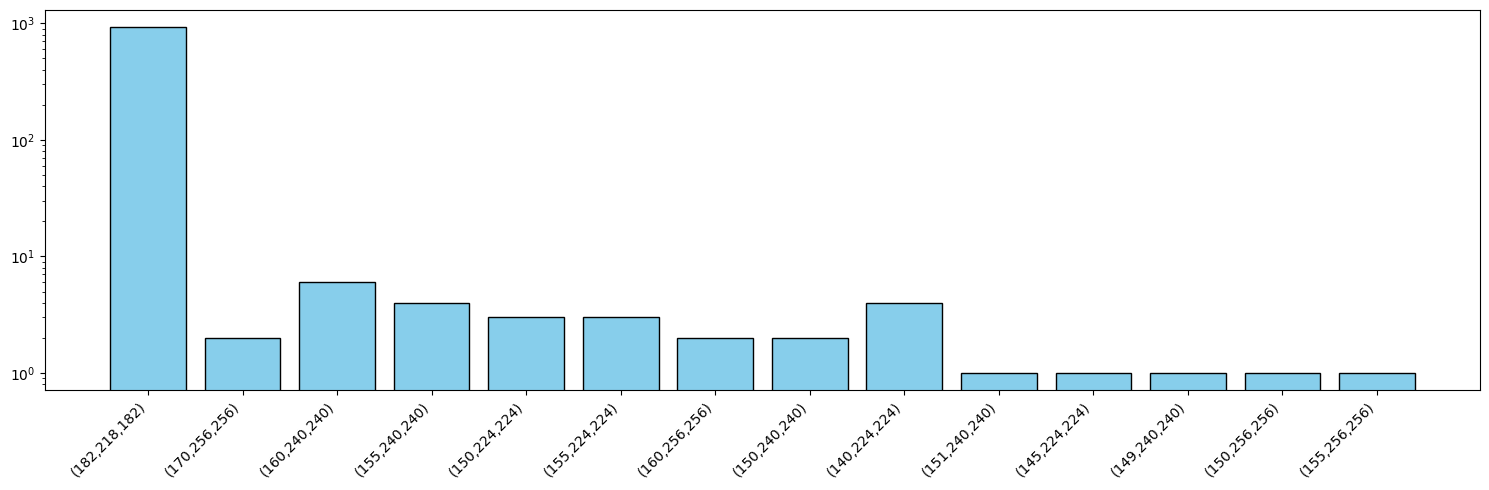

In [19]:
shapes = [
    nib.load(f"{DBB_DATASET_FOLDER}/{scans['SEGMENTATION FILEPATH']}").shape
    for scans in scans_filepath.values() 
]

counts = Counter(shapes)
fig, ax = plt.subplots(figsize=(15,5))
ax.bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
ax.set_yscale("log")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

## Voxel size

In [20]:
sizes = np.array([
    nib.load(f"{DBB_DATASET_FOLDER}/{scans['SEGMENTATION FILEPATH']}").header.get_zooms()
    for scans in list(scans_filepath.values())
])

t1_x_mean, t1_x_std = np.mean(sizes[:,0]), np.std(sizes[:,0])
t1_y_mean, t1_y_std = np.mean(sizes[:,1]), np.std(sizes[:,1])
t1_z_mean, t1_z_std = np.mean(sizes[:,2]), np.std(sizes[:,2])
print(f"[T1] ({t1_x_mean:.2f}±{t1_x_std:.2f}, {t1_y_mean:.2f}±{t1_y_std:.2f}, {t1_z_mean:.2f}±{t1_z_std:.2f})")

[T1] (1.00±0.00, 1.00±0.01, 1.00±0.01)


## Orientation

In [21]:
orientations = [
    "".join(nib.aff2axcodes(nib.load(f"{DBB_DATASET_FOLDER}/{scans['SEGMENTATION FILEPATH']}").affine))
    for scans in list(scans_filepath.values())
]

print(np.unique_counts(orientations))

UniqueCountsResult(values=array(['LAS', 'RAS'], dtype='<U3'), counts=array([943,  12]))


## Explore different centers

### C-MIND

In [30]:
subject_id = "0001"
subject_info = df[df["SUBJECT"] == subject_id].iloc[0]

# t1w_filepath = scans_filepath[subject_id]["T1-W FILEPATH"] # NOT AVAILABLE
segmentation_filepath = scans_filepath[subject_id]["SEGMENTATION FILEPATH"]
brain_mask_filepath = scans_filepath[subject_id]["BRAIN MASK FILEPATH"]
raw_brain_mask_filepath = scans_filepath[subject_id]["RAW BRAIN MASK FILEPATH"]

#nib_t1w = nib.load(f"{DBB_DATASET_FOLDER}/{t1w_filepath}")
nib_segmentation = nib.load(f"{DBB_DATASET_FOLDER}/{segmentation_filepath}")
nib_brain_mask = nib.load(f"{DBB_DATASET_FOLDER}/{brain_mask_filepath}")

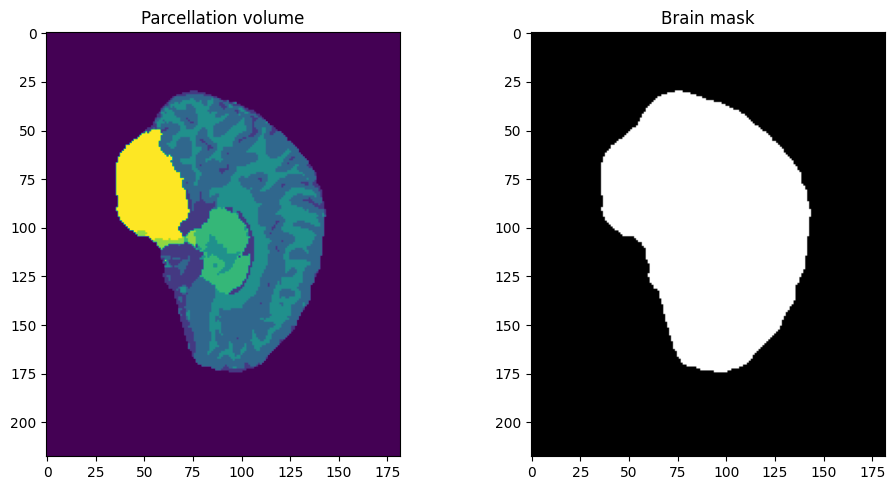

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

i = 100
#axs[0].imshow(nib_t1w.get_fdata()[i, :, :])
#axs[0].set_title("T1w")

axs[0].imshow(nib_segmentation.get_fdata()[i, :, :])
axs[0].set_title("Parcellation volume")

axs[1].imshow(nib_brain_mask.get_fdata()[i, :, :], cmap=plt.cm.gray)
axs[1].set_title("Brain mask")

plt.tight_layout()

### EMEDEA-PED

In [37]:
subject_id = "0415"
subject_info = df[df["SUBJECT"] == subject_id].iloc[0]

t1_filepath = scans_filepath[subject_id]["T1-W FILEPATH"]
segmentation_filepath = scans_filepath[subject_id]["SEGMENTATION FILEPATH"]
brain_mask_filepath = scans_filepath[subject_id]["BRAIN MASK FILEPATH"]
raw_brain_mask_filepath = scans_filepath[subject_id]["RAW BRAIN MASK FILEPATH"]

nib_t1 = nib.load(f"{DBB_DATASET_FOLDER}/{t1_filepath}")
nib_segmentation = nib.load(f"{DBB_DATASET_FOLDER}/{segmentation_filepath}")
nib_brain_mask = nib.load(f"{DBB_DATASET_FOLDER}/{brain_mask_filepath}")

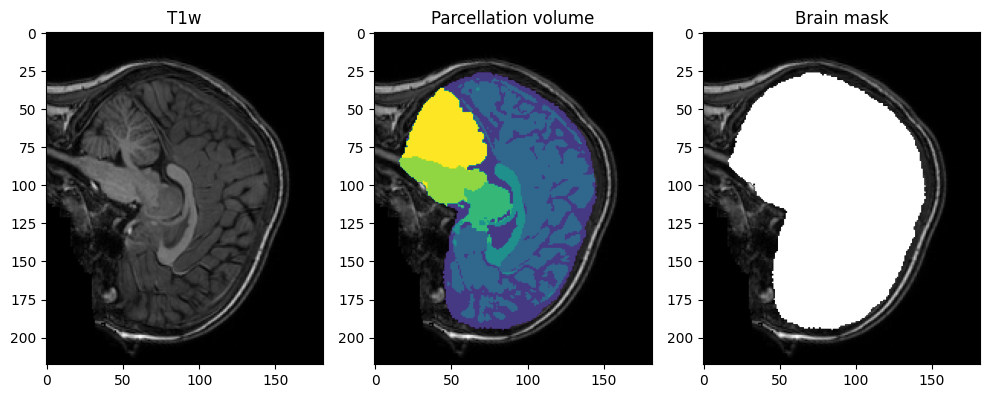

In [43]:
fig, axs = plt.subplots(1, 3, figsize=(10,5))

axs[0].imshow(nib_t1.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("T1w")

axs[1].imshow(nib_t1.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[1].imshow(nib_segmentation.get_fdata()[91, :, :], alpha=(nib_segmentation.get_fdata()[91, :, :] > 0).astype(float))
axs[1].set_title("Parcellation volume")

axs[2].imshow(nib_t1.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[2].imshow(nib_brain_mask.get_fdata()[91, :, :], cmap=plt.cm.gray, alpha=(nib_brain_mask.get_fdata()[91, :, :] > 0).astype(float))
axs[2].set_title("Brain mask")

plt.tight_layout()

### NIH-PED

In [44]:
subject_id = "0519"
subject_info = df[df["SUBJECT"] == subject_id].iloc[0]

segmentation_filepath = scans_filepath[subject_id]["SEGMENTATION FILEPATH"]
brain_mask_filepath = scans_filepath[subject_id]["BRAIN MASK FILEPATH"]
raw_brain_mask_filepath = scans_filepath[subject_id]["RAW BRAIN MASK FILEPATH"]

nib_segmentation = nib.load(f"{DBB_DATASET_FOLDER}/{segmentation_filepath}")
nib_brain_mask = nib.load(f"{DBB_DATASET_FOLDER}/{brain_mask_filepath}")

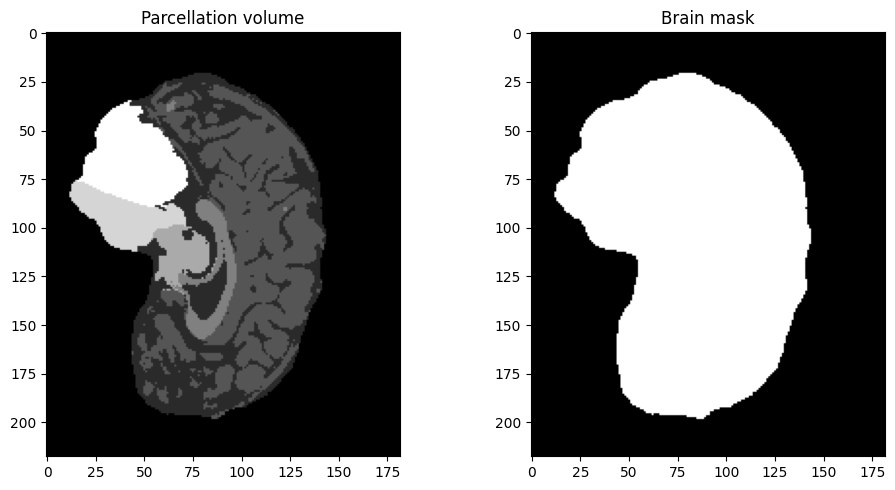

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].imshow(nib_segmentation.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[0].set_title("Parcellation volume")

axs[1].imshow(nib_brain_mask.get_fdata()[91, :, :], cmap=plt.cm.gray)
axs[1].set_title("Brain mask")

plt.tight_layout()

## Test set patients (the only ones with brain alterations)

In [41]:
df[df["SET"] == "test "]

,SUBJECT,ORIGINAL_ID,AGE,GENDER,SOURCE,CATEGORY,SET,ORIGINAL_FILENAME,MRI SEQUENCE,STATIC MAGNETIC FIELD,T1-W FILE,SEGMENTATION FILE,BRAIN MASK FILE,RAW BRAIN MASK FILE,AFFINE MATRIX FILE
918,0922,Anonymized,13.40,F,EMEDEA-PED,MCDs,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO
919,0923,Anonymized,17.80,M,EMEDEA-PED,MCDs,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO
920,0924,Anonymized,8.53,F,EMEDEA-PED,HD,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO
921,0925,Anonymized,8.53,M,EMEDEA-PED,ACC,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO
922,0926,Anonymized,3.20,F,EMEDEA-PED,PFM,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO
923,0927,Anonymized,5.90,F,EMEDEA-PED,MCDs,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO
924,0928,Anonymized,6.60,F,EMEDEA-PED,ACC,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO
925,0929,Anonymized,7.80,F,EMEDEA-PED,MCDs,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO
926,0930,Anonymized,9.50,F,EMEDEA-PED,ACC,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO
927,0931,Anonymized,1.40,M,EMEDEA-PED,PFM,test,Anonymized,3D T1-w MP-RAGE,3 T,YES,YES,YES,NO,NO


In [8]:
t1w_filepath = scans_filepath["0922"]["T1-W FILEPATH"]
t1w_filepath = f"{DBB_DATASET_FOLDER}/{t1w_filepath}"
segmentation_filepath = scans_filepath["0922"]["SEGMENTATION FILEPATH"]
segmentation_filepath = f"{DBB_DATASET_FOLDER}/{segmentation_filepath}"
mask_filepath = scans_filepath["0922"]["BRAIN MASK FILEPATH"]
mask_filepath = f"{DBB_DATASET_FOLDER}/{mask_filepath}"

explore_mri(t1w_filepath, segmentation_filepath, rotation=True, show_boundaries=True)

Output()

In [24]:
t1w_array = nib.load(t1w_filepath).get_fdata()
segmentation_array = nib.load(segmentation_filepath).get_fdata()
mask_array = nib.load(mask_filepath).get_fdata()

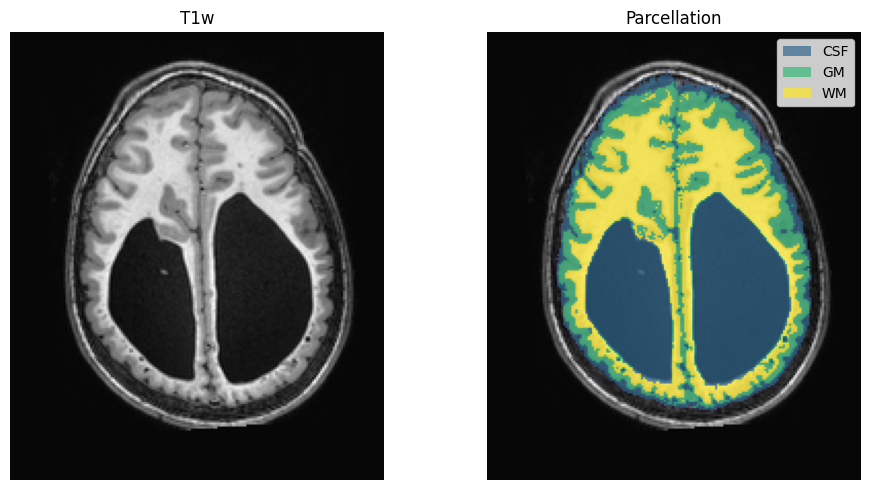

In [39]:
# 0 background 
# 1 "Cerebro-Spinal Fluid"
# 2 "Gray Matter"
# 3 "White Matter"

# removing extra labels
segmentation_array[np.isin(segmentation_array, [4, 5, 6])] = 0

# keeping only a slice and rotating it
i = 110

t1w_slice = np.rot90(t1w_array[:, :, i])
segmentation_slice = np.rot90(segmentation_array[:, :, i])

fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].imshow(t1w_slice, cmap=plt.cm.gray)
axs[0].set_title("T1w")
axs[0].set_axis_off()

axs[1].imshow(t1w_slice, cmap=plt.cm.gray)
axs[1].imshow(
    segmentation_slice, 
    alpha=(segmentation_slice > 0).astype(float) * 0.7,
    cmap = "viridis",
    vmin=0,
    vmax=3
)
axs[1].set_title("Parcellation")
axs[1].set_axis_off()

cmap = plt.get_cmap('viridis')

legend_elements = [
    Patch(facecolor=cmap(1/3), alpha=0.7, label='CSF'),
    Patch(facecolor=cmap(2/3), alpha=0.7, label='GM'),
    Patch(facecolor=cmap(3/3), alpha=0.7, label='WM')
]

axs[1].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()